# Week 8 - RLHF and Vision Transformers

Week 7 introduced transformers for sequence modeling. This week uses the same attention machinery in two new places.

The first part studies reinforcement learning from human feedback, or RLHF. RLHF is a training pipeline for aligning a model's behavior with preferences. The core idea is to learn a reward model from comparisons, then update a policy to produce outputs that score well under that reward model while staying close to the original model.

The second part studies vision transformers. A vision transformer turns an image into a sequence of patch tokens, adds a class token and positional embeddings, and applies the same transformer encoder blocks used in language models.

The goals are:

1. Explain why supervised fine-tuning alone does not fully specify preferred behavior.
2. Train a small reward model from pairwise preferences.
3. Use a KL-regularized policy update to improve a small policy with the learned reward.
4. Connect RLHF math to cross-entropy, preference probabilities, and policy gradients.
5. Convert images into patch tokens for a vision transformer.
6. Explain class tokens, position embeddings, multi-head self-attention, and transformer encoder blocks for images.
7. Train a small ViT-style classifier from scratch on Imagenette2.
8. Fine-tune an ImageNet-pretrained torchvision ViT on Imagenette2.
9. Compare convolutional inductive bias with the patch-token view used by ViTs.

The running image dataset is Imagenette2, a ten-class subset of ImageNet. It is much smaller than ImageNet but keeps the ImageNet-style setting that makes pretrained vision transformers useful.

## Imports and Device

The notebook uses PyTorch for all models. The RLHF section uses a tiny discrete response task so the whole pipeline is visible. The vision section uses `torchvision` datasets, transforms, and pretrained models.

In [1]:
# Core Python utilities
from pathlib import Path
from copy import deepcopy
import math
import random
import shutil
import tarfile
import time
import urllib.request

# Numerical and plotting tools
import numpy as np
import matplotlib.pyplot as plt

# PyTorch and torchvision tools
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, models
from torchvision.transforms import v2 as transforms

# Reporting tools
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

pin_memory = device.type == "cuda"
print(f"Using device: {device}")

Using device: cuda


## Plotting and Evaluation Helpers

These helpers appear near the top because both the RLHF and ViT sections use learning curves and classification metrics.

In [2]:
# Plot training curves stored in a shared history format
def plot_histories(histories, metric_name="validation_accuracy"):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    for name, history in histories.items():
        epochs = range(1, len(history["training_loss"]) + 1)
        plt.plot(epochs, history["training_loss"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("Training Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    for name, history in histories.items():
        epochs = range(1, len(history[metric_name]) + 1)
        best_value = max(history[metric_name])
        plt.plot(epochs, history[metric_name], label=f"{name} ({best_value:.3f})")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name.replace("_", " ").title())
    plt.title(metric_name.replace("_", " ").title())
    plt.legend()

    plt.tight_layout()
    plt.show()


# Compute multiclass accuracy from logits and labels
def accuracy_from_logits(logits, labels):
    predictions = logits.argmax(dim=1)
    return (predictions == labels).float().mean().item()

# Part 1: Reinforcement Learning from Human Feedback

Supervised learning teaches a model to imitate examples. For a prompt $x$ and target response $y$, supervised fine-tuning minimizes cross-entropy:

$$\mathcal{L}_{\text{SFT}}(\theta) = -\log \pi_\theta(y \mid x).$$

This is powerful, but it does not directly tell the model which of two plausible responses people prefer. RLHF adds a preference-learning stage.

A common pipeline is:

1. Start with a pretrained or supervised fine-tuned policy $\pi_{\text{ref}}(y \mid x)$.
2. Collect comparisons such as response $y^+$ preferred over response $y^-$ for the same prompt $x$.
3. Train a reward model $r_\phi(x,y)$ that assigns higher scores to preferred responses.
4. Optimize a policy $\pi_\theta$ to receive high reward while staying close to the reference policy.

The usual preference model is Bradley-Terry:

$$P(y^+ \succ y^- \mid x) = \sigma(r_\phi(x,y^+) - r_\phi(x,y^-)).$$

The reward model loss is binary cross-entropy on pairwise comparisons:

$$\mathcal{L}_{\text{reward}}(\phi) = -\log \sigma(r_\phi(x,y^+) - r_\phi(x,y^-)).$$

## A Tiny Preference Dataset

The toy task uses short prompts and a fixed set of possible responses. The response preferences are synthetic, but the training structure matches the real RLHF pipeline:

- a prompt is encoded as an ID,
- a response is encoded as an ID,
- a preference pair says which response is better for a prompt.

This keeps the mechanics visible without needing a large language model.

In [3]:
# Tiny prompt and response vocabulary for the RLHF demonstration
prompts = [
    "Write a helpful answer",
    "Write a concise answer",
    "Write a safe answer",
    "Write an encouraging answer",
    "Write a factual answer",
]

responses = [
    "direct helpful answer",
    "short answer",
    "refuses unsafe request",
    "warm encouraging answer",
    "careful factual answer",
    "vague generic answer",
    "overconfident unsupported answer",
    "needlessly long answer",
]

prompt_to_id = {prompt: index for index, prompt in enumerate(prompts)}
response_to_id = {response: index for index, response in enumerate(responses)}

# Ground-truth preference scores create synthetic pairwise labels
preference_score_table = torch.tensor([
    [4.0, 2.0, 1.0, 3.0, 3.0, 0.5, -1.0, 0.0],
    [2.0, 4.0, 1.0, 2.0, 2.0, 0.0, -1.0, 1.0],
    [1.0, 1.0, 5.0, 2.0, 3.0, 0.0, -2.0, -1.0],
    [3.0, 1.0, 1.0, 5.0, 2.0, 0.5, -1.0, 0.0],
    [2.0, 1.0, 2.0, 2.0, 5.0, 0.5, -2.0, -0.5],
])

print(f"Number of prompts: {len(prompts)}")
print(f"Number of candidate responses: {len(responses)}")

Number of prompts: 5
Number of candidate responses: 8


In [4]:
# Pairwise preference dataset sampled from the synthetic score table
class PreferencePairDataset(Dataset):
    def __init__(self, score_table, number_of_pairs=4000, seed=0):
        generator = torch.Generator().manual_seed(seed)
        pairs = []

        for _ in range(number_of_pairs):
            prompt_id = torch.randint(0, score_table.shape[0], (1,), generator=generator).item()
            first_response = torch.randint(0, score_table.shape[1], (1,), generator=generator).item()
            second_response = torch.randint(0, score_table.shape[1], (1,), generator=generator).item()

            while second_response == first_response:
                second_response = torch.randint(0, score_table.shape[1], (1,), generator=generator).item()

            first_score = score_table[prompt_id, first_response]
            second_score = score_table[prompt_id, second_response]

            if first_score >= second_score:
                chosen_response = first_response
                rejected_response = second_response
            else:
                chosen_response = second_response
                rejected_response = first_response

            pairs.append((prompt_id, chosen_response, rejected_response))

        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        prompt_id, chosen_response, rejected_response = self.pairs[index]
        return (
            torch.tensor(prompt_id, dtype=torch.long),
            torch.tensor(chosen_response, dtype=torch.long),
            torch.tensor(rejected_response, dtype=torch.long),
        )


preference_dataset = PreferencePairDataset(preference_score_table, number_of_pairs=4000, seed=SEED)
train_size = int(0.8 * len(preference_dataset))
val_size = len(preference_dataset) - train_size
preference_train_dataset, preference_val_dataset = random_split(
    preference_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

preference_train_loader = DataLoader(
    preference_train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory,
)
preference_val_loader = DataLoader(
    preference_val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

print(f"Preference train pairs: {len(preference_train_dataset)}")
print(f"Preference validation pairs: {len(preference_val_dataset)}")

Preference train pairs: 3200
Preference validation pairs: 800


## Reward Model

The reward model maps a prompt-response pair to one scalar:

$$r_\phi(x,y) \in \mathbb{R}.$$

Only reward differences matter for pairwise training. If the chosen response should beat the rejected response, the model should make

$$r_\phi(x,y^+) - r_\phi(x,y^-)$$

large and positive.

In [5]:
# Reward model with prompt and response embeddings
class TinyRewardModel(nn.Module):
    def __init__(self, number_of_prompts, number_of_responses, embedding_dim=32, hidden_dim=64):
        super().__init__()
        self.prompt_embedding = nn.Embedding(number_of_prompts, embedding_dim)
        self.response_embedding = nn.Embedding(number_of_responses, embedding_dim)
        self.scorer = nn.Sequential(
            nn.Linear(2 * embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, prompt_ids, response_ids):
        prompt_vectors = self.prompt_embedding(prompt_ids)
        response_vectors = self.response_embedding(response_ids)
        pair_vectors = torch.cat([prompt_vectors, response_vectors], dim=1)
        return self.scorer(pair_vectors).squeeze(1)


def reward_preference_loss(chosen_scores, rejected_scores):
    return -F.logsigmoid(chosen_scores - rejected_scores).mean()

reward_model | Epoch 001 | Train Loss: 0.4910 | Val Loss: 0.3659 | Val Pref Acc: 0.8988
reward_model | Epoch 002 | Train Loss: 0.2904 | Val Loss: 0.2459 | Val Pref Acc: 0.9050
reward_model | Epoch 003 | Train Loss: 0.2053 | Val Loss: 0.1838 | Val Pref Acc: 0.9425
reward_model | Epoch 004 | Train Loss: 0.1579 | Val Loss: 0.1447 | Val Pref Acc: 0.9537
reward_model | Epoch 005 | Train Loss: 0.1263 | Val Loss: 0.1212 | Val Pref Acc: 0.9587
reward_model | Epoch 006 | Train Loss: 0.1048 | Val Loss: 0.1024 | Val Pref Acc: 0.9625
reward_model | Epoch 007 | Train Loss: 0.0910 | Val Loss: 0.0909 | Val Pref Acc: 0.9625
reward_model | Epoch 008 | Train Loss: 0.0815 | Val Loss: 0.0818 | Val Pref Acc: 0.9712
reward_model | Epoch 009 | Train Loss: 0.0742 | Val Loss: 0.0757 | Val Pref Acc: 0.9675
reward_model | Epoch 010 | Train Loss: 0.0691 | Val Loss: 0.0722 | Val Pref Acc: 0.9712
reward_model | Epoch 011 | Train Loss: 0.0667 | Val Loss: 0.0699 | Val Pref Acc: 0.9625
reward_model | Epoch 012 | Train

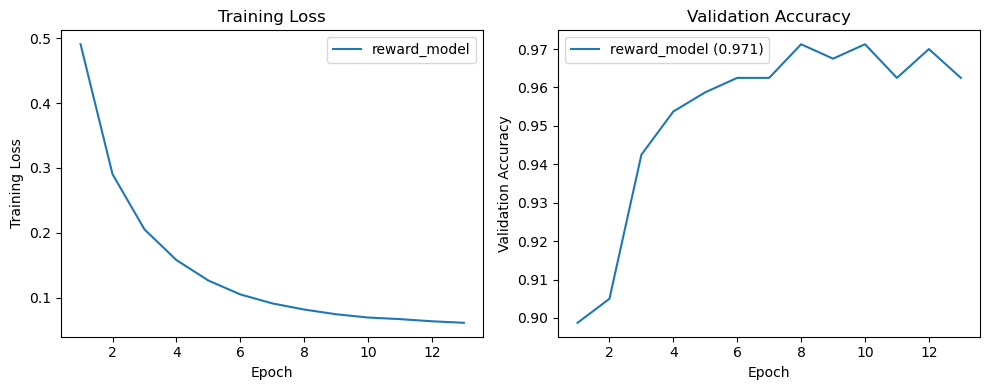

In [6]:
# Train the reward model with early stopping on validation preference accuracy
def train_reward_model(model, train_loader, val_loader, max_epochs=50, patience=5, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    history = {"training_loss": [], "validation_loss": [], "validation_accuracy": []}

    best_state = None
    best_val_accuracy = 0.0
    epochs_without_improvement = 0

    for epoch_index in range(max_epochs):
        model.train()
        total_training_loss = 0.0

        for prompt_ids, chosen_ids, rejected_ids in train_loader:
            prompt_ids = prompt_ids.to(device, non_blocking=True)
            chosen_ids = chosen_ids.to(device, non_blocking=True)
            rejected_ids = rejected_ids.to(device, non_blocking=True)

            chosen_scores = model(prompt_ids, chosen_ids)
            rejected_scores = model(prompt_ids, rejected_ids)
            loss = reward_preference_loss(chosen_scores, rejected_scores)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            total_training_loss += loss.item() * prompt_ids.size(0)

        model.eval()
        total_validation_loss = 0.0
        total_correct = 0
        total_examples = 0

        with torch.no_grad():
            for prompt_ids, chosen_ids, rejected_ids in val_loader:
                prompt_ids = prompt_ids.to(device, non_blocking=True)
                chosen_ids = chosen_ids.to(device, non_blocking=True)
                rejected_ids = rejected_ids.to(device, non_blocking=True)

                chosen_scores = model(prompt_ids, chosen_ids)
                rejected_scores = model(prompt_ids, rejected_ids)
                loss = reward_preference_loss(chosen_scores, rejected_scores)

                total_validation_loss += loss.item() * prompt_ids.size(0)
                total_correct += (chosen_scores > rejected_scores).sum().item()
                total_examples += prompt_ids.size(0)

        training_loss = total_training_loss / len(train_loader.dataset)
        validation_loss = total_validation_loss / len(val_loader.dataset)
        validation_accuracy = total_correct / total_examples

        history["training_loss"].append(training_loss)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        print(
            f"reward_model | Epoch {epoch_index + 1:03d} | "
            f"Train Loss: {training_loss:.4f} | Val Loss: {validation_loss:.4f} | "
            f"Val Pref Acc: {validation_accuracy:.4f}"
        )

        if validation_accuracy > best_val_accuracy:
            best_val_accuracy = validation_accuracy
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping reward_model at epoch {epoch_index + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


reward_model = TinyRewardModel(
    number_of_prompts=len(prompts),
    number_of_responses=len(responses),
)
reward_model, reward_history = train_reward_model(
    reward_model,
    preference_train_loader,
    preference_val_loader,
    max_epochs=50,
    patience=5,
    lr=1e-3,
)
plot_histories({"reward_model": reward_history})

## Reference Policy and KL Penalty

RLHF does not usually optimize reward alone. If the policy chases the reward model too aggressively, it may exploit reward-model mistakes. A common objective adds a penalty for moving too far from a reference policy:

$$J(\theta) = \mathbb{E}_{y \sim \pi_\theta(\cdot \mid x)}\left[r_\phi(x,y) - \beta \log \frac{\pi_\theta(y \mid x)}{\pi_{\text{ref}}(y \mid x)}\right].$$

The second term is a sampled version of a KL penalty. The coefficient $\beta$ controls how conservative the update is.

The toy policy below directly learns a categorical distribution over possible responses for each prompt.

In [7]:
# Tiny policy that maps a prompt ID to response logits
class TinyResponsePolicy(nn.Module):
    def __init__(self, number_of_prompts, number_of_responses, embedding_dim=32):
        super().__init__()
        self.prompt_embedding = nn.Embedding(number_of_prompts, embedding_dim)
        self.policy_head = nn.Linear(embedding_dim, number_of_responses)

    def forward(self, prompt_ids):
        prompt_vectors = self.prompt_embedding(prompt_ids)
        return self.policy_head(prompt_vectors)

    def log_probabilities(self, prompt_ids):
        logits = self(prompt_ids)
        return logits.log_softmax(dim=1)


# Supervised targets choose the highest-scoring synthetic response for each prompt
sft_prompt_ids = torch.arange(len(prompts), dtype=torch.long)
sft_target_response_ids = preference_score_table.argmax(dim=1).long()
sft_dataset = torch.utils.data.TensorDataset(sft_prompt_ids, sft_target_response_ids)
sft_loader = DataLoader(sft_dataset, batch_size=len(sft_dataset), shuffle=True)

In [8]:
# Supervised fine-tuning creates the reference policy used by RLHF
def train_reference_policy(model, train_loader, max_epochs=100, lr=1e-2):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_function = nn.CrossEntropyLoss()

    for epoch_index in range(max_epochs):
        model.train()
        for prompt_ids, target_response_ids in train_loader:
            prompt_ids = prompt_ids.to(device)
            target_response_ids = target_response_ids.to(device)

            logits = model(prompt_ids)
            loss = loss_function(logits, target_response_ids)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

    return model


reference_policy = TinyResponsePolicy(len(prompts), len(responses))
reference_policy = train_reference_policy(reference_policy, sft_loader, max_epochs=100, lr=1e-2)
rlhf_policy = deepcopy(reference_policy)

for parameter in reference_policy.parameters():
    parameter.requires_grad = False
reference_policy.eval()

TinyResponsePolicy(
  (prompt_embedding): Embedding(5, 32)
  (policy_head): Linear(in_features=32, out_features=8, bias=True)
)

In [9]:
# Display the most likely response from a policy for each prompt
def show_policy_choices(policy, title):
    policy.eval()
    prompt_ids = torch.arange(len(prompts), dtype=torch.long, device=device)

    with torch.no_grad():
        probabilities = policy(prompt_ids).softmax(dim=1).cpu()

    print(title)
    for prompt_index, prompt in enumerate(prompts):
        response_index = probabilities[prompt_index].argmax().item()
        probability = probabilities[prompt_index, response_index].item()
        print(f"{prompt:<30} -> {responses[response_index]:<32} p={probability:.3f}")


show_policy_choices(reference_policy, "Reference policy choices")

Reference policy choices
Write a helpful answer         -> direct helpful answer            p=0.998
Write a concise answer         -> short answer                     p=0.998
Write a safe answer            -> refuses unsafe request           p=0.998
Write an encouraging answer    -> warm encouraging answer          p=0.999
Write a factual answer         -> careful factual answer           p=0.998


In [10]:
# KL-regularized policy optimization using sampled responses
prompt_sampling_ids = torch.arange(len(prompts), dtype=torch.long, device=device)
policy_optimizer = torch.optim.AdamW(rlhf_policy.parameters(), lr=5e-3, weight_decay=1e-4)
kl_beta = 0.15
number_of_policy_steps = 200
rlhf_history = {"training_loss": [], "mean_reward": [], "mean_kl_penalty": []}

reward_model.eval()
reference_policy.eval()
rlhf_policy.train()

for step_index in range(number_of_policy_steps):
    logits = rlhf_policy(prompt_sampling_ids)
    distribution = torch.distributions.Categorical(logits=logits)
    sampled_response_ids = distribution.sample()
    sampled_log_probs = distribution.log_prob(sampled_response_ids)

    with torch.no_grad():
        reference_log_probs = reference_policy.log_probabilities(prompt_sampling_ids)
        sampled_reference_log_probs = reference_log_probs.gather(1, sampled_response_ids[:, None]).squeeze(1)
        rewards = reward_model(prompt_sampling_ids, sampled_response_ids)

    kl_sample = sampled_log_probs - sampled_reference_log_probs
    objective = rewards - kl_beta * kl_sample
    loss = -(sampled_log_probs * objective.detach()).mean()

    policy_optimizer.zero_grad(set_to_none=True)
    loss.backward()
    policy_optimizer.step()

    rlhf_history["training_loss"].append(loss.item())
    rlhf_history["mean_reward"].append(rewards.mean().item())
    rlhf_history["mean_kl_penalty"].append(kl_sample.mean().item())

    if (step_index + 1) % 25 == 0:
        print(
            f"Step {step_index + 1:03d} | "
            f"Policy Loss: {loss.item():.4f} | "
            f"Mean Reward: {rewards.mean().item():.4f} | "
            f"Mean KL Sample: {kl_sample.mean().item():.4f}"
        )

show_policy_choices(rlhf_policy, "RLHF policy choices")

Step 025 | Policy Loss: 0.0003 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 050 | Policy Loss: 0.0001 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 075 | Policy Loss: 0.0001 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 100 | Policy Loss: 0.0001 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 125 | Policy Loss: 0.0000 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 150 | Policy Loss: 0.0000 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 175 | Policy Loss: 0.0000 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
Step 200 | Policy Loss: 0.0000 | Mean Reward: 5.5310 | Mean KL Sample: 0.0019
RLHF policy choices
Write a helpful answer         -> direct helpful answer            p=1.000
Write a concise answer         -> short answer                     p=1.000
Write a safe answer            -> refuses unsafe request           p=1.000
Write an encouraging answer    -> warm encouraging answer          p=1.000
Write a factual answer         -> careful factual answer

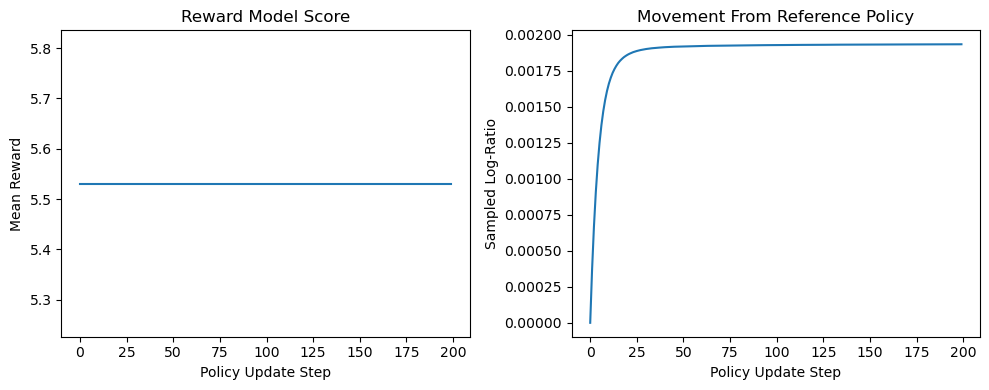

In [11]:
# Plot reward and KL behavior during the toy RLHF update
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(rlhf_history["mean_reward"])
plt.xlabel("Policy Update Step")
plt.ylabel("Mean Reward")
plt.title("Reward Model Score")

plt.subplot(1, 2, 2)
plt.plot(rlhf_history["mean_kl_penalty"])
plt.xlabel("Policy Update Step")
plt.ylabel("Sampled Log-Ratio")
plt.title("Movement From Reference Policy")

plt.tight_layout()
plt.show()

## RLHF Takeaways

RLHF turns subjective or hard-to-write-down preferences into a training signal. The main mathematical pieces are:

- supervised fine-tuning: imitate good examples,
- preference modeling: learn $r_\phi(x,y)$ from comparisons,
- policy optimization: increase reward while controlling distance from a reference policy.

The KL term matters because the reward model is only an approximation. It is usually safer to improve the policy gradually than to let it search freely for reward-model loopholes.

Modern alternatives such as direct preference optimization, or DPO, avoid an explicit reinforcement-learning loop by optimizing a preference objective directly against a reference policy. The conceptual ingredients are still the same: preferences, a reference model, and a penalty for drifting too far from the original behavior.

# Part 2: Vision Transformers

A convolutional network treats an image as a grid and builds in local spatial bias through kernels. A vision transformer treats an image as a sequence of patches.

For an image $x \in \mathbb{R}^{C \times H \times W}$ and patch size $P$, the number of patches is

$$N = \frac{H}{P} \cdot \frac{W}{P}.$$

Each patch is flattened and projected into a token vector:

$$z_i = x_i W_E + b_E.$$

A learned class token is prepended, position embeddings are added, and the sequence is processed by transformer encoder blocks:

$$Z^{(0)} = [z_{\text{cls}}, z_1, \ldots, z_N] + E_{\text{pos}}.$$

The final class-token representation is used for classification.

## Imagenette2 Data

Imagenette2 is a ten-class subset of ImageNet. It is small enough for class notebooks but still contains natural images at ImageNet-like scale.

The notebook uses the 160-pixel version to keep downloads and training manageable. The pretrained ViT section resizes images to 224 pixels because torchvision ImageNet weights expect that input size.

In [12]:
# Download and extract Imagenette2-160 if needed
DATA_ROOT = Path("../../datasets")
IMAGENETTE_ROOT = DATA_ROOT / "imagenette2-160"
IMAGENETTE_ARCHIVE = DATA_ROOT / "imagenette2-160.tgz"
IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"

if not IMAGENETTE_ROOT.exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    if not IMAGENETTE_ARCHIVE.exists():
        print("Downloading Imagenette2-160")
        urllib.request.urlretrieve(IMAGENETTE_URL, IMAGENETTE_ARCHIVE)

    print("Extracting Imagenette2-160")
    with tarfile.open(IMAGENETTE_ARCHIVE, "r:gz") as tar:
        tar.extractall(path=DATA_ROOT)

print(f"Imagenette root: {IMAGENETTE_ROOT}")

Extracting Imagenette2-160
Imagenette root: ../../datasets/imagenette2-160


In [13]:
# Imagenette class names for readable reports
imagenette_class_names = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute",
}

# Imagenette normalization follows ImageNet statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

vit_scratch_train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=(160, 160), scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

vit_scratch_eval_transforms = transforms.Compose([
    transforms.Resize(size=(160, 160)),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

pretrained_vit_train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

pretrained_vit_eval_transforms = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [14]:
# Dataset wrappers let train and validation use different transforms on the same image files
class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform
        self.classes = base_dataset.classes
        self.class_to_idx = base_dataset.class_to_idx

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        base_index = self.indices[index]
        path, label = self.base_dataset.samples[base_index]
        image = self.base_dataset.loader(path)
        image = self.transform(image)
        return image, label


base_train_dataset = datasets.ImageFolder(IMAGENETTE_ROOT / "train")
base_val_dataset = datasets.ImageFolder(IMAGENETTE_ROOT / "val")

class_names = [imagenette_class_names.get(name, name) for name in base_train_dataset.classes]
print(class_names)
print(f"Training images: {len(base_train_dataset)}")
print(f"Validation images: {len(base_val_dataset)}")

['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']
Training images: 9469
Validation images: 3925


In [15]:
# Deterministic subsets keep the notebook practical while still using Imagenette2
IMAGENETTE_TRAIN_SUBSET_SIZE = 7000
IMAGENETTE_VAL_SUBSET_SIZE = 2000
IMAGENETTE_BATCH_SIZE = 64
IMAGENETTE_NUM_WORKERS = 2

train_indices = torch.randperm(
    len(base_train_dataset),
    generator=torch.Generator().manual_seed(SEED),
)[:IMAGENETTE_TRAIN_SUBSET_SIZE].tolist()

val_indices = torch.randperm(
    len(base_val_dataset),
    generator=torch.Generator().manual_seed(SEED),
)[:IMAGENETTE_VAL_SUBSET_SIZE].tolist()

scratch_train_dataset = TransformSubset(base_train_dataset, train_indices, vit_scratch_train_transforms)
scratch_val_dataset = TransformSubset(base_val_dataset, val_indices, vit_scratch_eval_transforms)

scratch_train_loader = DataLoader(
    scratch_train_dataset,
    batch_size=IMAGENETTE_BATCH_SIZE,
    shuffle=True,
    num_workers=IMAGENETTE_NUM_WORKERS,
    pin_memory=pin_memory,
)
scratch_val_loader = DataLoader(
    scratch_val_dataset,
    batch_size=IMAGENETTE_BATCH_SIZE,
    shuffle=False,
    num_workers=IMAGENETTE_NUM_WORKERS,
    pin_memory=pin_memory,
)

print(f"Scratch train subset: {len(scratch_train_dataset)}")
print(f"Scratch validation subset: {len(scratch_val_dataset)}")

Scratch train subset: 7000
Scratch validation subset: 2000


## Patch Embeddings

A ViT patch embedding is often implemented as a convolution:

- kernel size = patch size,
- stride = patch size,
- output channels = embedding dimension.

This creates one embedding vector per non-overlapping patch. For a $160 \times 160$ image with $16 \times 16$ patches, there are $10 \times 10 = 100$ patch tokens.

In [16]:
# Patch embedding layer for ViT-style models
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=160, patch_size=16, in_channels=3, embedding_dim=192):
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError("image_size must be divisible by patch_size")

        self.image_size = image_size
        self.patch_size = patch_size
        self.number_of_patches = (image_size // patch_size) ** 2
        self.projection = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embedding_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, images):
        patch_grid = self.projection(images)
        patch_tokens = patch_grid.flatten(2).transpose(1, 2)
        return patch_tokens


images, labels = next(iter(scratch_train_loader))
patch_embedding = PatchEmbedding(image_size=160, patch_size=16, embedding_dim=192)
patch_tokens = patch_embedding(images)

print(f"Image batch shape: {tuple(images.shape)}")
print(f"Patch token shape: {tuple(patch_tokens.shape)}")

Image batch shape: (64, 3, 160, 160)
Patch token shape: (64, 100, 192)


## A Small Vision Transformer From Scratch

The small ViT below follows the basic ViT recipe:

1. split image into patch tokens,
2. prepend a learned class token,
3. add learned positional embeddings,
4. pass the sequence through transformer encoder layers,
5. classify from the final class token.

This model is intentionally smaller than standard ViT-B/16. Training a large transformer from scratch usually needs far more data than Imagenette2.

In [17]:
# Compact ViT classifier for Imagenette2
class SmallVisionTransformer(nn.Module):
    def __init__(
        self,
        image_size=160,
        patch_size=16,
        number_of_classes=10,
        embedding_dim=192,
        depth=4,
        number_of_heads=4,
        mlp_dim=384,
        dropout=0.1,
    ):
        super().__init__()
        self.patch_embedding = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=3,
            embedding_dim=embedding_dim,
        )
        number_of_patches = self.patch_embedding.number_of_patches

        self.class_token = nn.Parameter(torch.zeros(1, 1, embedding_dim))
        self.position_embedding = nn.Parameter(torch.zeros(1, number_of_patches + 1, embedding_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=number_of_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embedding_dim)
        self.classifier = nn.Linear(embedding_dim, number_of_classes)

        nn.init.trunc_normal_(self.class_token, std=0.02)
        nn.init.trunc_normal_(self.position_embedding, std=0.02)

    def forward(self, images):
        patch_tokens = self.patch_embedding(images)
        batch_size = patch_tokens.size(0)
        class_tokens = self.class_token.expand(batch_size, -1, -1)
        tokens = torch.cat([class_tokens, patch_tokens], dim=1)
        tokens = tokens + self.position_embedding
        tokens = self.dropout(tokens)
        encoded_tokens = self.encoder(tokens)
        class_representation = self.norm(encoded_tokens[:, 0])
        return self.classifier(class_representation)


small_vit = SmallVisionTransformer(number_of_classes=len(class_names))
with torch.no_grad():
    logits = small_vit(images)
print(f"Small ViT logits shape: {tuple(logits.shape)}")

/home/rwhite/.local/share/mamba/envs/xai-s26/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Small ViT logits shape: (64, 10)


In [18]:
# General image classifier trainer with early stopping
def train_image_classifier(
    model,
    train_loader,
    val_loader,
    *,
    model_name,
    max_epochs=30,
    patience=5,
    lr=1e-3,
    weight_decay=1e-4,
):
    model = model.to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"training_loss": [], "validation_loss": [], "validation_accuracy": []}
    best_state = None
    best_val_accuracy = 0.0
    epochs_without_improvement = 0

    for epoch_index in range(max_epochs):
        start_time = time.time()
        model.train()
        total_training_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = loss_function(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            total_training_loss += loss.item() * images.size(0)

        model.eval()
        total_validation_loss = 0.0
        total_correct = 0
        total_examples = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                logits = model(images)
                loss = loss_function(logits, labels)

                total_validation_loss += loss.item() * images.size(0)
                total_correct += (logits.argmax(dim=1) == labels).sum().item()
                total_examples += images.size(0)

        training_loss = total_training_loss / len(train_loader.dataset)
        validation_loss = total_validation_loss / len(val_loader.dataset)
        validation_accuracy = total_correct / total_examples

        history["training_loss"].append(training_loss)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        elapsed = time.time() - start_time
        print(
            f"{model_name:<18} | Epoch {epoch_index + 1:03d} | "
            f"Train Loss: {training_loss:.4f} | Val Loss: {validation_loss:.4f} | "
            f"Val Acc: {validation_accuracy:.4f} | Time: {elapsed:.1f}s"
        )

        if validation_accuracy > best_val_accuracy:
            best_val_accuracy = validation_accuracy
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping {model_name} at epoch {epoch_index + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

small_vit          | Epoch 001 | Train Loss: 1.9872 | Val Loss: 1.8478 | Val Acc: 0.3630 | Time: 3.1s
small_vit          | Epoch 002 | Train Loss: 1.7330 | Val Loss: 1.7072 | Val Acc: 0.4130 | Time: 3.0s
small_vit          | Epoch 003 | Train Loss: 1.5913 | Val Loss: 1.5542 | Val Acc: 0.4655 | Time: 3.5s
small_vit          | Epoch 004 | Train Loss: 1.4763 | Val Loss: 1.5463 | Val Acc: 0.4685 | Time: 3.1s
small_vit          | Epoch 005 | Train Loss: 1.3996 | Val Loss: 1.4726 | Val Acc: 0.4995 | Time: 3.4s
small_vit          | Epoch 006 | Train Loss: 1.3457 | Val Loss: 1.4167 | Val Acc: 0.5215 | Time: 3.2s
small_vit          | Epoch 007 | Train Loss: 1.3079 | Val Loss: 1.4428 | Val Acc: 0.5150 | Time: 3.3s
small_vit          | Epoch 008 | Train Loss: 1.2791 | Val Loss: 1.4106 | Val Acc: 0.5165 | Time: 3.5s
small_vit          | Epoch 009 | Train Loss: 1.2242 | Val Loss: 1.3381 | Val Acc: 0.5460 | Time: 3.1s
small_vit          | Epoch 010 | Train Loss: 1.1930 | Val Loss: 1.3707 | Val Acc: 

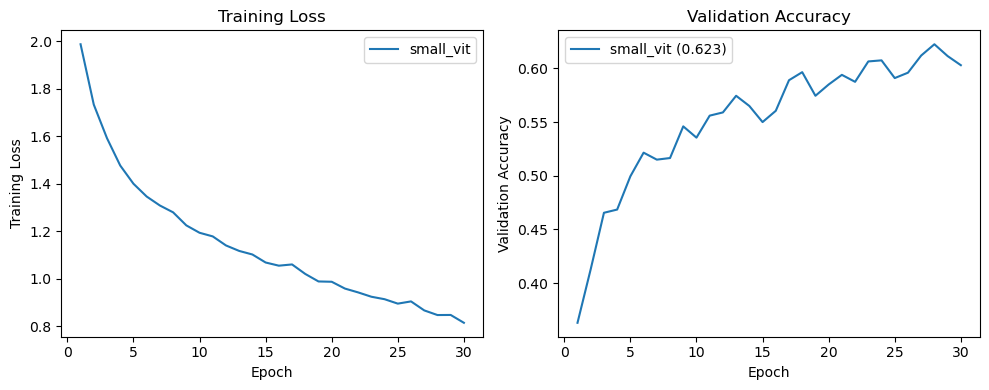

In [19]:
# Train the small ViT from scratch on Imagenette2
small_vit = SmallVisionTransformer(number_of_classes=len(class_names))
small_vit, small_vit_history = train_image_classifier(
    small_vit,
    scratch_train_loader,
    scratch_val_loader,
    model_name="small_vit",
    max_epochs=30,
    patience=5,
    lr=3e-4,
    weight_decay=5e-2,
)
plot_histories({"small_vit": small_vit_history})

## Evaluating Image Classifiers

Validation accuracy is useful during training, but confusion matrices show which classes are being confused. Imagenette2 has visually different categories, so many mistakes reveal whether the model has learned shape, texture, or background cues.

                  precision    recall  f1-score   support

           tench       0.73      0.79      0.76       181
English springer       0.55      0.73      0.63       200
 cassette player       0.53      0.55      0.54       196
       chain saw       0.49      0.42      0.45       202
          church       0.67      0.46      0.55       196
     French horn       0.65      0.67      0.66       213
   garbage truck       0.61      0.69      0.65       206
        gas pump       0.55      0.58      0.57       211
       golf ball       0.72      0.57      0.63       197
       parachute       0.79      0.77      0.78       198

        accuracy                           0.62      2000
       macro avg       0.63      0.62      0.62      2000
    weighted avg       0.63      0.62      0.62      2000



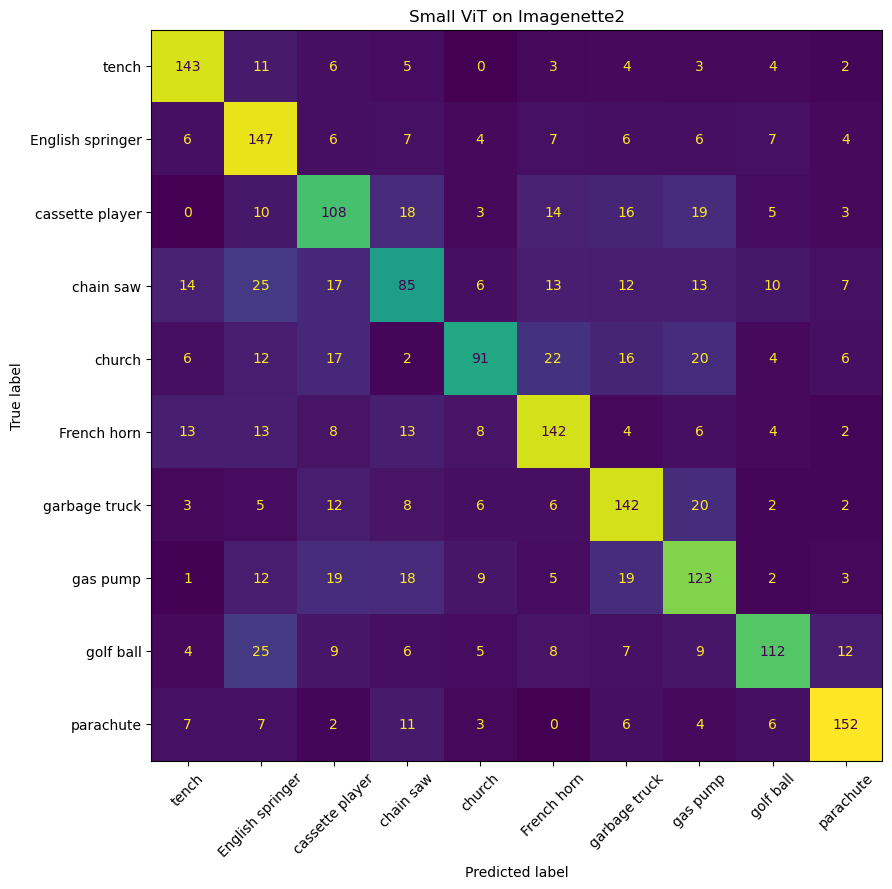

In [20]:
# Evaluation helper for Imagenette classifiers
def evaluate_image_classifier(model, data_loader, class_names, title):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            logits = model(images)
            predictions = logits.argmax(dim=1).cpu()

            all_predictions.extend(predictions.tolist())
            all_labels.extend(labels.tolist())

    print(classification_report(all_labels, all_predictions, target_names=class_names))

    matrix = confusion_matrix(all_labels, all_predictions)
    display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(9, 9))
    display.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


evaluate_image_classifier(small_vit, scratch_val_loader, class_names, "Small ViT on Imagenette2")

## Pretrained Vision Transformer Fine-Tuning

The original ViT result was strongest when the model was pretrained on very large datasets. On smaller datasets, a ViT trained from scratch can be data-hungry because it has less built-in locality than a CNN.

Transfer learning changes the setup. An ImageNet-pretrained ViT already has useful patch, shape, and object features. Fine-tuning adapts those features to Imagenette2.

In [21]:
# Build Imagenette loaders for pretrained ViT input size
pretrained_train_dataset = TransformSubset(base_train_dataset, train_indices, pretrained_vit_train_transforms)
pretrained_val_dataset = TransformSubset(base_val_dataset, val_indices, pretrained_vit_eval_transforms)

pretrained_train_loader = DataLoader(
    pretrained_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=IMAGENETTE_NUM_WORKERS,
    pin_memory=pin_memory,
)
pretrained_val_loader = DataLoader(
    pretrained_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=IMAGENETTE_NUM_WORKERS,
    pin_memory=pin_memory,
)

print(f"Pretrained ViT train subset: {len(pretrained_train_dataset)}")
print(f"Pretrained ViT validation subset: {len(pretrained_val_dataset)}")

Pretrained ViT train subset: 7000
Pretrained ViT validation subset: 2000


In [22]:
# Load an ImageNet-pretrained ViT and replace the classifier head
vit_weights = models.ViT_B_16_Weights.IMAGENET1K_V1
pretrained_vit = models.vit_b_16(weights=vit_weights)

in_features = pretrained_vit.heads.head.in_features
pretrained_vit.heads.head = nn.Linear(in_features, len(class_names))

for name, parameter in pretrained_vit.named_parameters():
    parameter.requires_grad = name.startswith("heads")

pretrained_vit = pretrained_vit.to(device)
print(pretrained_vit.heads)

Sequential(
  (head): Linear(in_features=768, out_features=10, bias=True)
)


In [23]:
# Train only the new classifier head first
pretrained_vit, vit_head_history = train_image_classifier(
    pretrained_vit,
    pretrained_train_loader,
    pretrained_val_loader,
    model_name="vit_head",
    max_epochs=20,
    patience=5,
    lr=1e-3,
    weight_decay=1e-4,
)

vit_head           | Epoch 001 | Train Loss: 0.1562 | Val Loss: 0.0225 | Val Acc: 0.9980 | Time: 9.3s
vit_head           | Epoch 002 | Train Loss: 0.0139 | Val Loss: 0.0143 | Val Acc: 0.9980 | Time: 9.3s
vit_head           | Epoch 003 | Train Loss: 0.0072 | Val Loss: 0.0114 | Val Acc: 0.9980 | Time: 9.3s
vit_head           | Epoch 004 | Train Loss: 0.0043 | Val Loss: 0.0106 | Val Acc: 0.9980 | Time: 9.3s
vit_head           | Epoch 005 | Train Loss: 0.0024 | Val Loss: 0.0099 | Val Acc: 0.9980 | Time: 9.3s
vit_head           | Epoch 006 | Train Loss: 0.0025 | Val Loss: 0.0096 | Val Acc: 0.9975 | Time: 9.3s
Early stopping vit_head at epoch 6


vit_finetune       | Epoch 001 | Train Loss: 0.0107 | Val Loss: 0.0135 | Val Acc: 0.9980 | Time: 11.1s
vit_finetune       | Epoch 002 | Train Loss: 0.0050 | Val Loss: 0.0109 | Val Acc: 0.9975 | Time: 11.2s
vit_finetune       | Epoch 003 | Train Loss: 0.0023 | Val Loss: 0.0105 | Val Acc: 0.9985 | Time: 11.2s
vit_finetune       | Epoch 004 | Train Loss: 0.0020 | Val Loss: 0.0097 | Val Acc: 0.9990 | Time: 11.1s
vit_finetune       | Epoch 005 | Train Loss: 0.0013 | Val Loss: 0.0096 | Val Acc: 0.9985 | Time: 11.2s
vit_finetune       | Epoch 006 | Train Loss: 0.0009 | Val Loss: 0.0092 | Val Acc: 0.9985 | Time: 11.2s
vit_finetune       | Epoch 007 | Train Loss: 0.0007 | Val Loss: 0.0097 | Val Acc: 0.9980 | Time: 11.2s
vit_finetune       | Epoch 008 | Train Loss: 0.0006 | Val Loss: 0.0102 | Val Acc: 0.9980 | Time: 11.2s
vit_finetune       | Epoch 009 | Train Loss: 0.0004 | Val Loss: 0.0093 | Val Acc: 0.9980 | Time: 11.2s
Early stopping vit_finetune at epoch 9


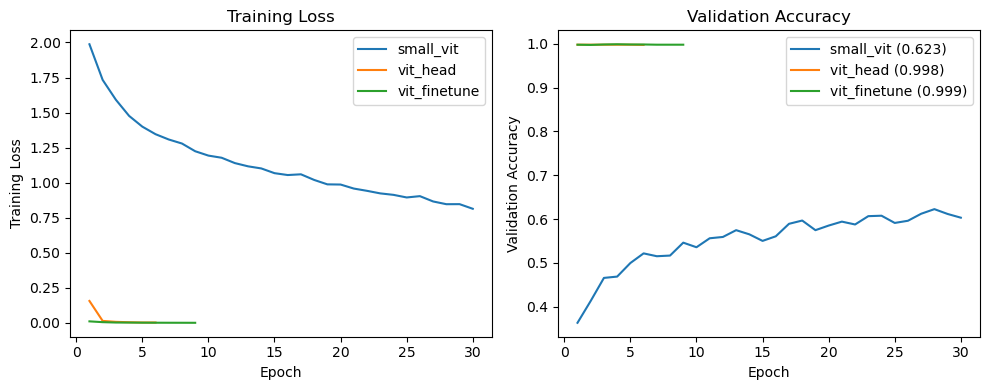

In [24]:
# Unfreeze the final encoder blocks for a short fine-tuning phase
for name, parameter in pretrained_vit.named_parameters():
    if name.startswith("encoder.layers.encoder_layer_10"):
        parameter.requires_grad = True
    if name.startswith("encoder.layers.encoder_layer_11"):
        parameter.requires_grad = True
    if name.startswith("heads"):
        parameter.requires_grad = True

pretrained_vit, vit_finetune_history = train_image_classifier(
    pretrained_vit,
    pretrained_train_loader,
    pretrained_val_loader,
    model_name="vit_finetune",
    max_epochs=20,
    patience=5,
    lr=1e-5,
    weight_decay=1e-4,
)

plot_histories({
    "small_vit": small_vit_history,
    "vit_head": vit_head_history,
    "vit_finetune": vit_finetune_history,
})

                  precision    recall  f1-score   support

           tench       1.00      1.00      1.00       181
English springer       1.00      1.00      1.00       200
 cassette player       1.00      1.00      1.00       196
       chain saw       1.00      1.00      1.00       202
          church       1.00      1.00      1.00       196
     French horn       1.00      1.00      1.00       213
   garbage truck       1.00      1.00      1.00       206
        gas pump       1.00      1.00      1.00       211
       golf ball       1.00      1.00      1.00       197
       parachute       0.99      1.00      1.00       198

        accuracy                           1.00      2000
       macro avg       1.00      1.00      1.00      2000
    weighted avg       1.00      1.00      1.00      2000



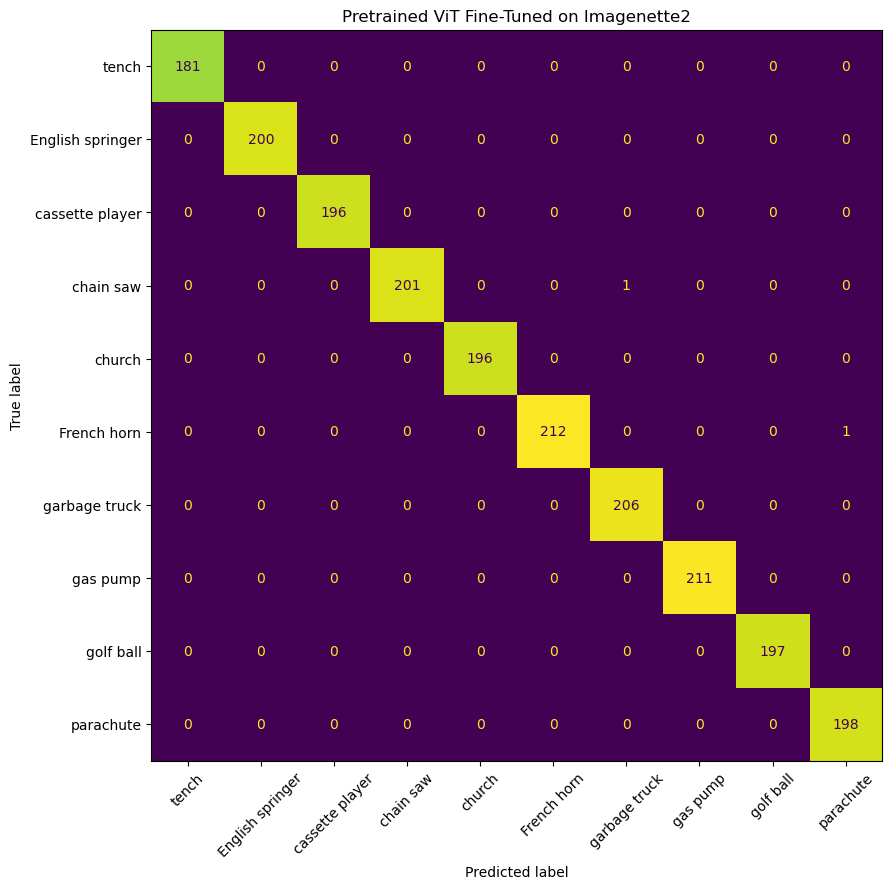

In [25]:
# Evaluate the fine-tuned pretrained ViT
evaluate_image_classifier(
    pretrained_vit,
    pretrained_val_loader,
    class_names,
    "Pretrained ViT Fine-Tuned on Imagenette2",
)

## ViT Takeaways

Vision transformers reuse transformer encoder ideas from language, but the input sequence is made from image patches instead of word or subword tokens.

The main architectural pieces are:

- patch embedding: image patches become token vectors,
- class token: a learned summary token for classification,
- position embedding: spatial order information,
- multi-head self-attention: each patch can attend to all other patches,
- MLP block: per-token nonlinear processing,
- residual connections and layer normalization: stable deep training.

The practical lesson is that ViTs are powerful but data-hungry. A small ViT trained from scratch on Imagenette2 is a useful teaching model. A pretrained ViT is the realistic modern workflow.

## Week 8 Summary

RLHF and vision transformers look different on the surface, but both extend the transformer toolkit from Week 7.

RLHF changes the training signal. Instead of only asking the model to imitate examples, it learns from comparisons and optimizes a policy against a reward model with a KL penalty.

Vision transformers change the input representation. Instead of treating images as convolutional feature maps, they treat images as sequences of patch tokens and apply transformer encoder blocks.

The shared theme is that model behavior depends on both architecture and objective. ViTs show how attention can be moved into computer vision. RLHF shows how preference data can reshape what a model does after supervised learning.